In [1]:
# --- Rutas del proyecto -------------------------------------------------
from mayanlab.paths import ensure, project

RESULTS = project("mms_asr").results
ensure(RESULTS)

In [2]:
from huggingface_hub import notebook_login
notebook_login()

## Fusión MMS + KenLM (shallow fusion)

Como MMS es un modelo basado en CTC, no genera una probabilidad completa sobre secuencias de palabras como haría un HMM-GMM clásico. Por eso el LM no se combina con Bayes puro, sino en el propio decodificador, ponderando log-probabilidades:

$$\hat{W} = \arg\max_{W} \Big[ \log p_{\text{CTC}}(W \mid \boldsymbol{O}) + \alpha \log p_{\text{LM}}(W) + \beta \, |W| \Big]$$

- **$p_{\text{CTC}}(W \mid O)$**: verosimilitud acústica que aporta MMS a partir de las probabilidades por frame.
- **$p_{\text{LM}}(W)$**: probabilidad de la secuencia según el trigramas entrenado con KenLM.
- **$\alpha$**: peso del LM frente al modelo acústico.
- **$\beta$**: bono de inserción de palabras, compensa el sesgo hacia secuencias cortas.

Este esquema (*shallow fusion*) es el que aplican librerías como `pyctcdecode` al decodificar un modelo CTC junto con un LM externo tipo KenLM.

Para lograr esto necesitamos encontrar los valores óptimos $\alpha$ y $\beta$, con lo que utilizamos nuestro dataset de validación y obtuvimos estos resultados

In [3]:
import matplotlib.pyplot as plt
from datasets import load_dataset

ds_grid = load_dataset(
    "mau-cr/mms_yua_results",
    data_files="lm/lm_grid_search_val.csv",
    split="train",
)
df_grid_search = ds_grid.to_pandas()
df_grid_search



,alpha,beta,wer_val,cer_val
0,0.3,0.5,0.213813,0.091479
1,0.3,1.0,0.217597,0.092423
2,0.3,1.5,0.222800,0.093281
3,0.3,2.0,0.224693,0.093109
4,0.5,0.5,0.195837,0.088218
5,0.5,1.0,0.198202,0.088218
6,0.5,1.5,0.197256,0.088046
7,0.5,2.0,0.197256,0.088132
8,0.7,0.5,0.187323,0.085300
9,0.7,1.0,0.186377,0.084442


### Grid search over $\alpha$ and $\beta$

One cell per combination evaluated on the validation split. Colour encodes magnitude
(single hue, lighter is better) and the value is written in the cell, because on a 5 x 4
grid the number is what the reader wants. WER and CER peak at different points, so they
get one panel each with its own scale.

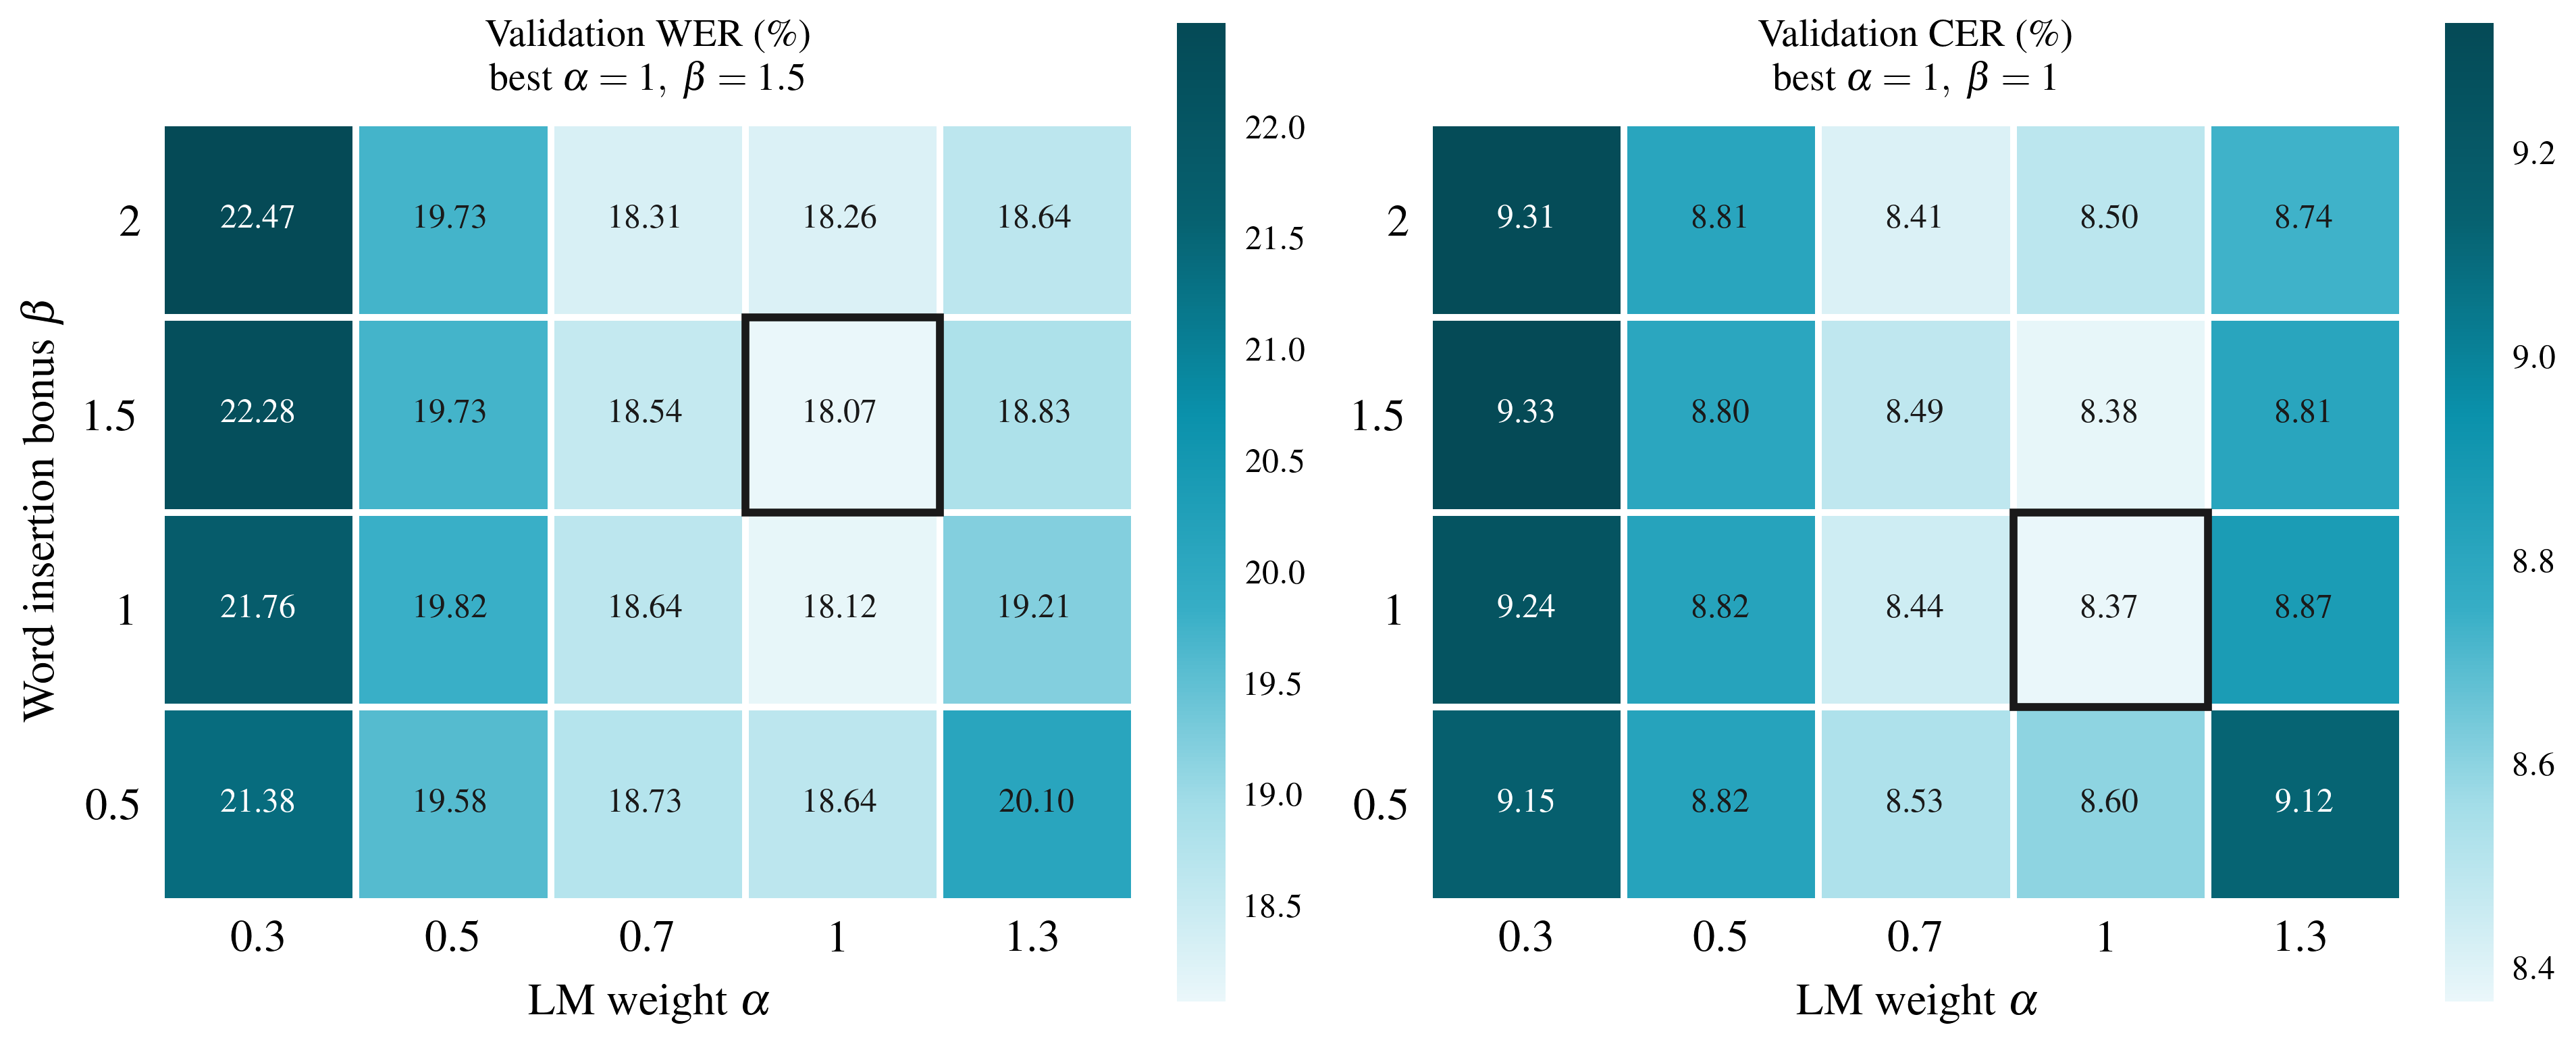

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401  (registers the "science" and "ieee" styles)
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# Single-hue sequential ramp anchored on the teal of the other figures (#0A91AB).
CMAP = LinearSegmentedColormap.from_list(
    "teal", ["#EAF7FA", "#A3DDE8", "#37AEC6", "#0A91AB", "#066170", "#054A56"])
INK = "#1A1A1A"

with plt.style.context(["science", "ieee"]):
    fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.9))

    for ax, (col, title) in zip(axes, [("wer_val", r"Validation WER (\%)"),
                                       ("cer_val", r"Validation CER (\%)")]):
        grid = df_grid_search.pivot(index="beta", columns="alpha", values=col) * 100
        Z, alphas, betas = grid.to_numpy(), grid.columns.to_numpy(), grid.index.to_numpy()
        norm = plt.Normalize(Z.min(), Z.max())

        mesh = ax.pcolormesh(np.arange(len(alphas) + 1), np.arange(len(betas) + 1), Z,
                             cmap=CMAP, edgecolors="white", linewidth=1.2)

        for (i, j), v in np.ndenumerate(Z):
            ax.text(j + .5, i + .5, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if norm(v) > .55 else INK)

        i, j = np.unravel_index(Z.argmin(), Z.shape)   # ring the optimum
        ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor=INK, lw=1.4, zorder=5))
        ax.set_title(title + "\n" + rf"best $\alpha={alphas[j]:g},\ \beta={betas[i]:g}$",
                     fontsize=7, pad=6)

        ax.set_xticks(np.arange(len(alphas)) + .5, [f"{a:g}" for a in alphas])
        ax.set_yticks(np.arange(len(betas)) + .5, [f"{b:g}" for b in betas])
        ax.set_xlabel(r"LM weight $\alpha$")
        ax.set_aspect("equal")
        ax.tick_params(length=0, which="both")
        ax.spines[:].set_visible(False)

        cbar = fig.colorbar(mesh, ax=ax, fraction=.046, pad=.04)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(length=0, which="both", labelsize=6)
        cbar.ax.minorticks_off()

    axes[0].set_ylabel(r"Word insertion bonus $\beta$")
    fig.tight_layout()
    for path in (RESULTS / "lm_grid_search_alpha_beta.svg",
                 RESULTS / "lm_grid_search_alpha_beta_paper.pdf"):
        fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset(
    "mau-cr/mms_yua_results",
    data_files="scaling_results.csv",
    split="train",
)
df = ds.to_pandas()

In [6]:
ds.to_pandas()

,audio_minutes,wer_greedy,cer_greedy,wer_lm,cer_lm
0,20,0.533764,0.178228,0.242649,0.111447
1,40,0.493053,0.164059,0.239418,0.106456
2,60,0.480775,0.160177,0.221002,0.099556
3,80,0.465913,0.155372,0.210339,0.095983
4,100,0.451373,0.148411,0.217771,0.096907
5,120,0.427787,0.141511,0.198708,0.089207
6,140,0.421971,0.138553,0.194184,0.089268
7,160,0.431664,0.139108,0.196769,0.087790
8,180,0.405493,0.133132,0.174798,0.077748
9,200,0.404523,0.131838,0.174475,0.080520


<Figure size 1000x1000 with 0 Axes>

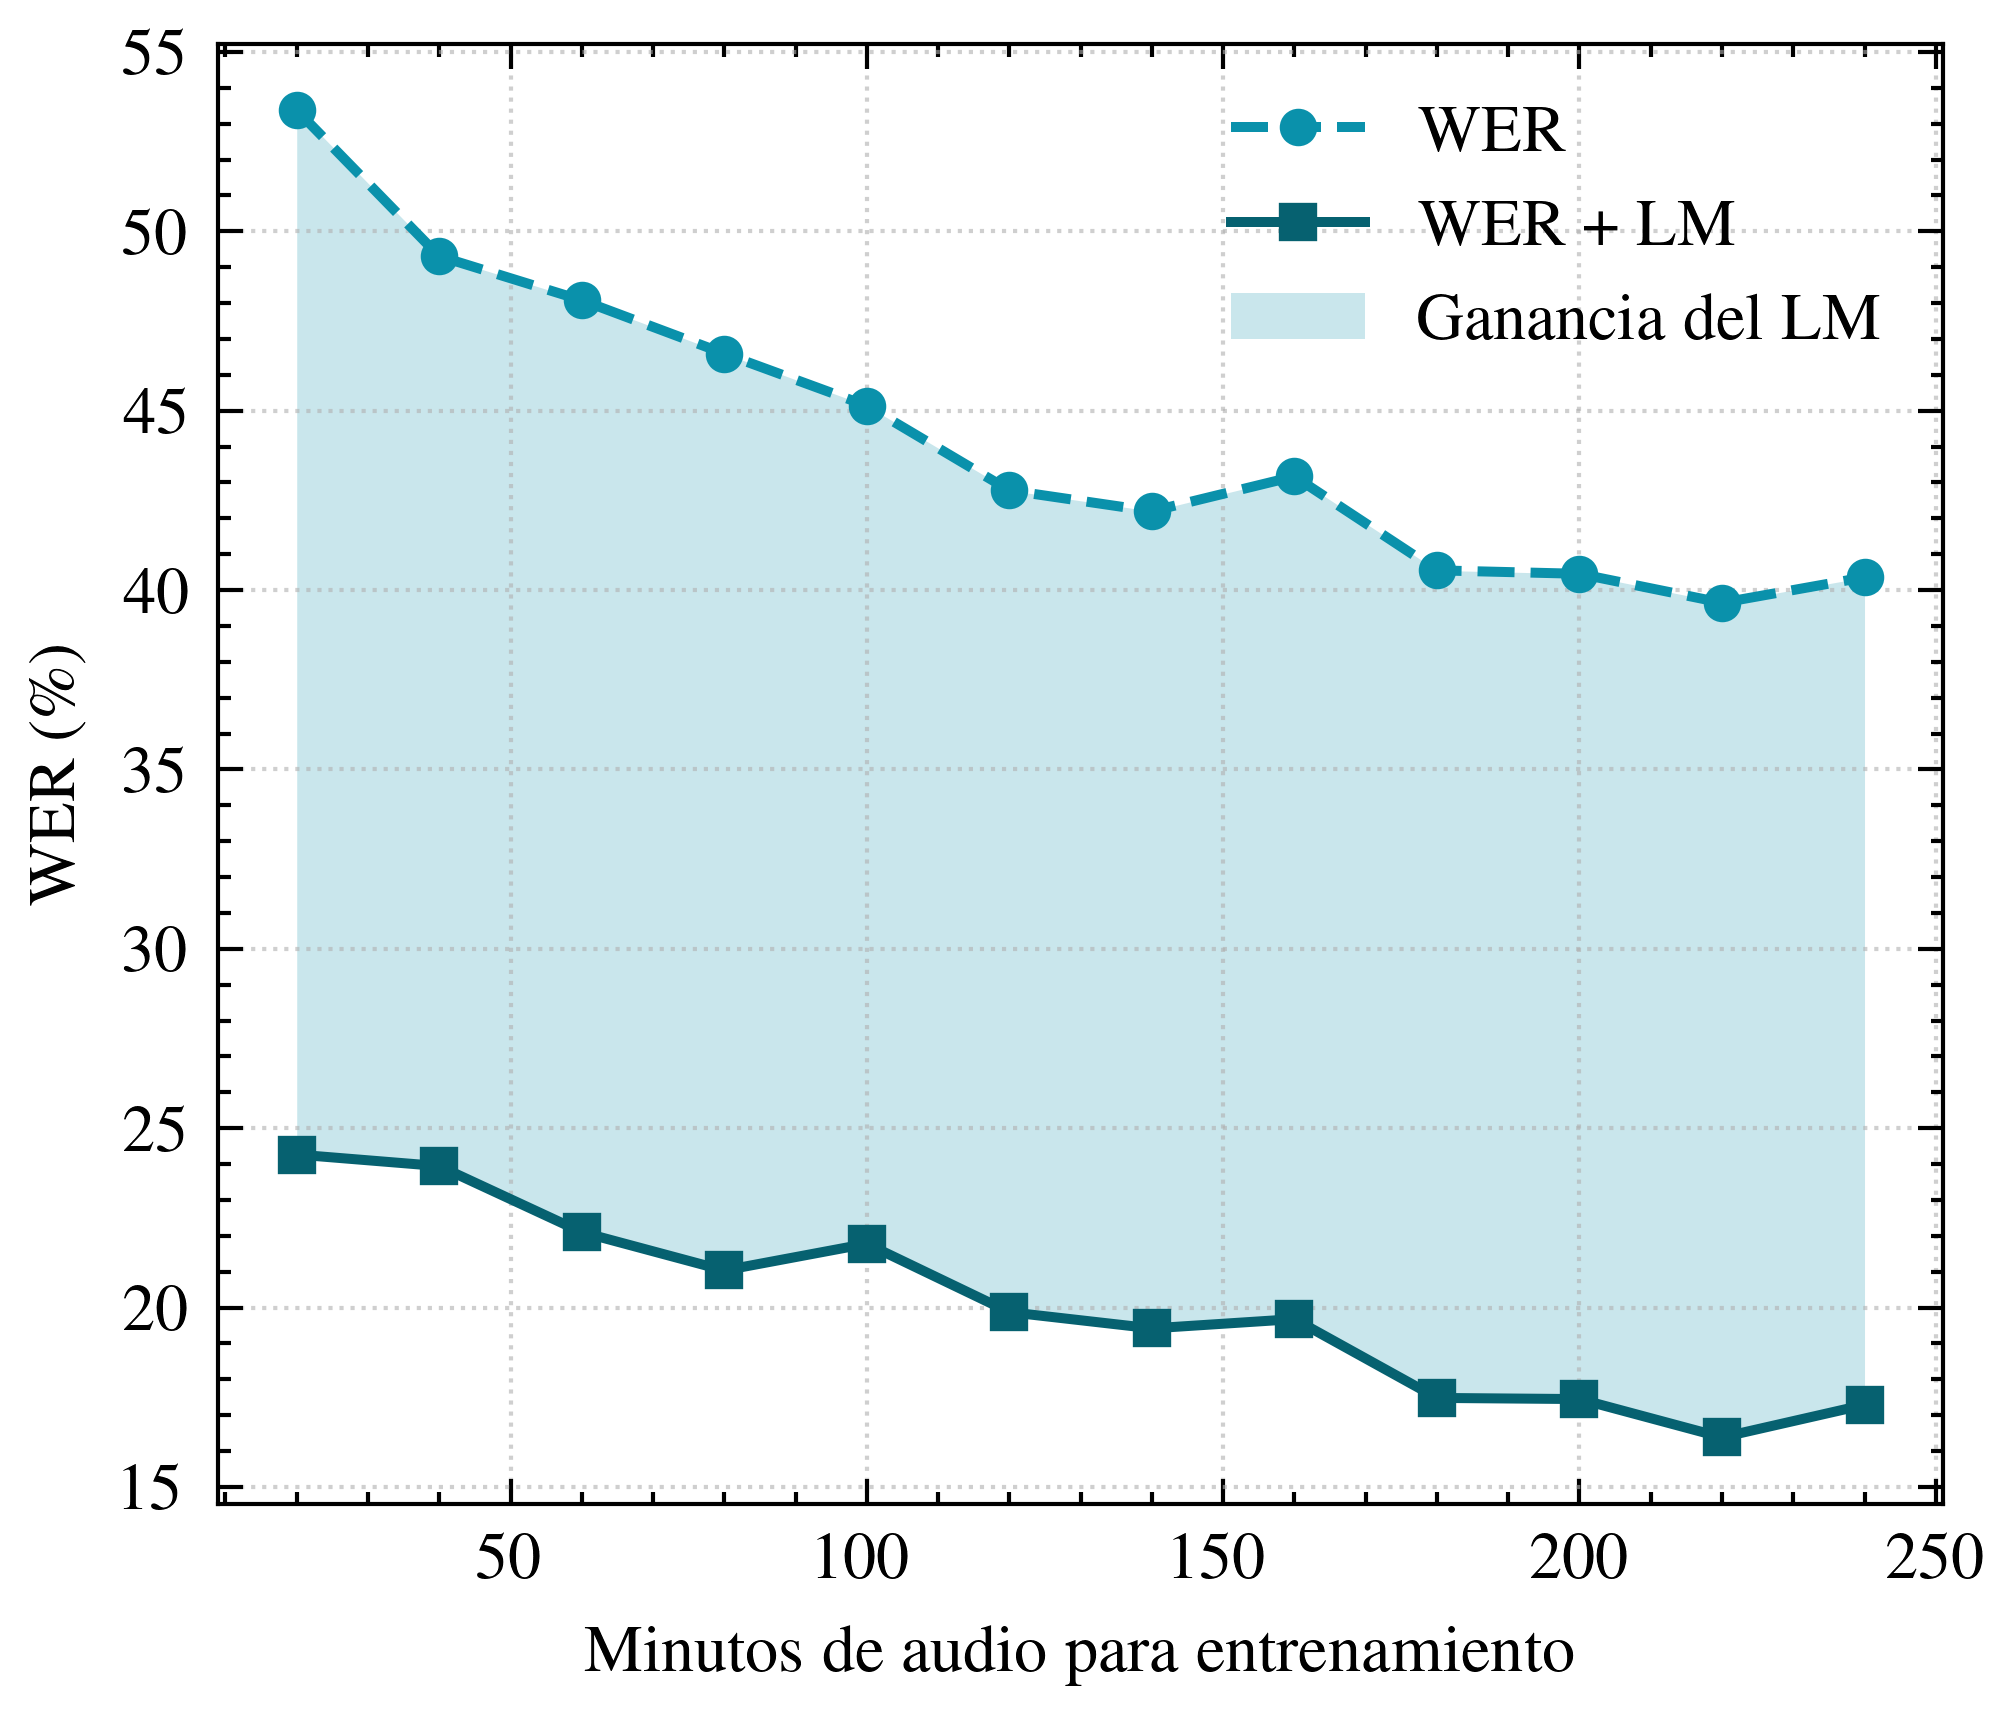

In [7]:
import matplotlib.pyplot as plt
import scienceplots

# 2. Ordenar por minutos de audio (clave para que las líneas y el área se vean limpias)
df = df.sort_values("audio_minutes").reset_index(drop=True)

x  = df["audio_minutes"].to_numpy()
y1 = df["wer_greedy"].to_numpy() * 100
y2 = df["wer_lm"].to_numpy() * 100

# 3. Paleta
BLUE       = "#0A91AB"   # el azul que pediste
BLUE_DEEP  = "#066170"   # versión más oscura del mismo tono, para WER + LM
BLUE_SOFT  = "#0A91AB"   # mismo azul pero con alpha bajo, para el sombreado

# 4. Gráfica con estilo science + ieee
fig = plt.figure(figsize=(10, 10))
with plt.style.context(["science", "ieee"]):

    fig, ax = plt.subplots(figsize=(3.5, 3.0))  # tamaños IEEE-friendly

    ax.plot(x, y1,
            linestyle="--", linewidth=1.2,
            color=BLUE, marker="o", markersize=3.5,
            label="WER")

    ax.plot(x, y2,
            linestyle="-", linewidth=1.2,
            color=BLUE_DEEP, marker="s", markersize=3.5,
            label="WER + LM")

    # Área sombreada entre las dos curvas
    ax.fill_between(x, y1, y2,
                    color=BLUE_SOFT, alpha=0.22,
                    linewidth=0,
                    label="Ganancia del LM")

    ax.set_xlabel("Minutos de audio para entrenamiento")
    ax.set_ylabel("WER (\\%)")          # escapa el % porque science usa LaTeX
    ax.legend(loc="best", frameon=False)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

    plt.tight_layout()
    plt.savefig(RESULTS / "wer_vs_audio_minutes.svg", dpi=300, bbox_inches="tight")
    plt.show()

<Figure size 1000x1000 with 0 Axes>

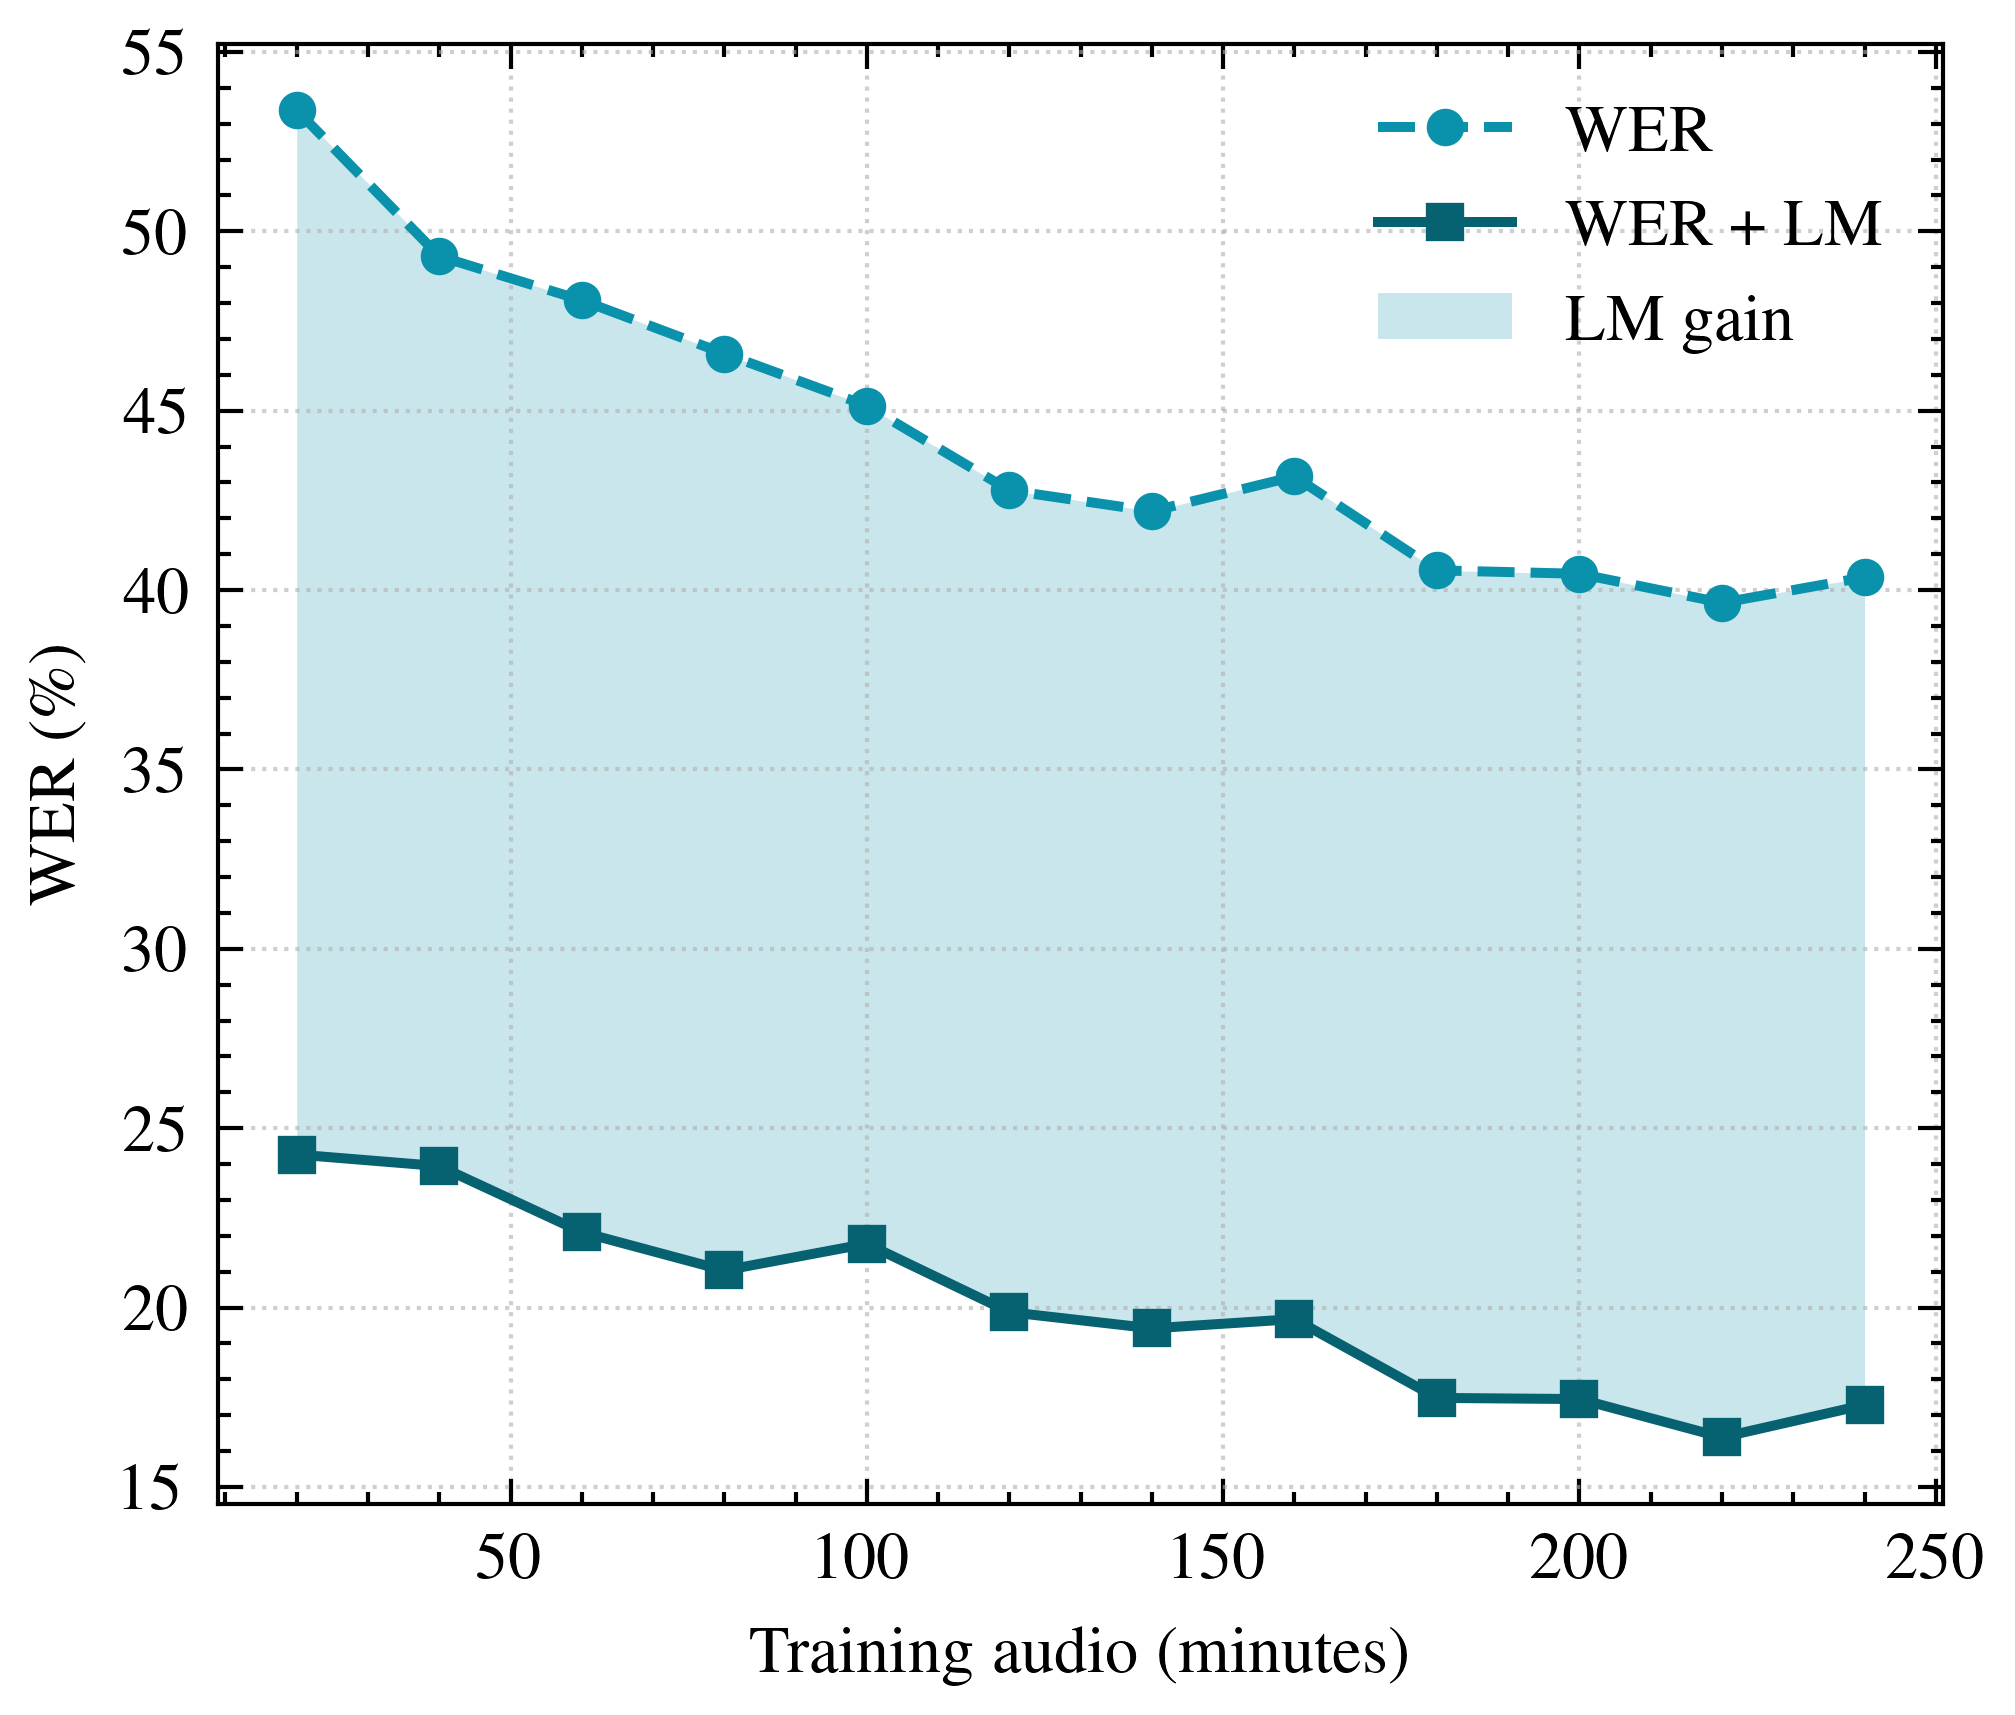

In [8]:
import matplotlib.pyplot as plt
import scienceplots

# 2. Ordenar por minutos de audio (clave para que las líneas y el área se vean limpias)
df = df.sort_values("audio_minutes").reset_index(drop=True)

x  = df["audio_minutes"].to_numpy()
y1 = df["wer_greedy"].to_numpy() * 100
y2 = df["wer_lm"].to_numpy() * 100

# 3. Paleta
BLUE       = "#0A91AB"   # el azul que pediste
BLUE_DEEP  = "#066170"   # versión más oscura del mismo tono, para WER + LM
BLUE_SOFT  = "#0A91AB"   # mismo azul pero con alpha bajo, para el sombreado

# 4. Gráfica con estilo science + ieee
fig = plt.figure(figsize=(10, 10))
with plt.style.context(["science", "ieee"]):

    fig, ax = plt.subplots(figsize=(3.5, 3.0))  # tamaños IEEE-friendly

    ax.plot(x, y1,
            linestyle="--", linewidth=1.2,
            color=BLUE, marker="o", markersize=3.5,
            label="WER")

    ax.plot(x, y2,
            linestyle="-", linewidth=1.2,
            color=BLUE_DEEP, marker="s", markersize=3.5,
            label="WER + LM")

    # Área sombreada entre las dos curvas
    ax.fill_between(x, y1, y2,
                     color=BLUE_SOFT, alpha=0.22,
                     linewidth=0,
                     label="LM gain")

    ax.set_xlabel("Training audio (minutes)")
    ax.set_ylabel("WER (\\%)")          # escapa el % porque science usa LaTeX
    ax.legend(loc="best", frameon=False)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

    plt.tight_layout()
    plt.savefig(RESULTS / "wer_vs_audio_minutes_paper.pdf", dpi=300, bbox_inches="tight", format="pdf")
    plt.show()